# Main ML Pipeline
## IMPORTANT: This notebook serves as the master/central execution file for the entire ML project pipeline. All modular pipleine notebooks (data collection through final evaluation) must be executed sequentially through this master pipeline to generate and feed required outputs.

In [1]:
!pip install ipynb
!pip install matplotlib seaborn pandas numpy
!pip install xgboost
!pip install imbalanced-learn

In [2]:
# Notebook 01_data_collect
%run 01_data_collect.ipynb

collector = DataCollector()
expected_rows = 5110
expected_cols = [
    "id", "gender", "age", "hypertension", "heart_disease",
    "ever_married", "work_type", "Residence_type",
    "avg_glucose_level", "bmi", "smoking_status", "stroke"
]

X_splits, y_splits = collector.split_data(expected_rows, expected_cols)

Partition row count match with original dataset.
Class proportions reasonably preserved.


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
2226,35602,Female,52.0,0,0,Yes,Govt_job,Rural,107.84,22.0,formerly smoked,0
3927,56137,Female,62.0,0,0,Yes,Private,Urban,88.32,36.3,Unknown,0
3358,14063,Male,81.0,0,1,No,Self-employed,Rural,95.49,29.4,Unknown,0
4152,12857,Male,55.0,0,0,Yes,Self-employed,Rural,73.57,28.0,smokes,0
4866,5875,Female,37.0,0,0,Yes,Private,Urban,103.66,36.1,smokes,0


,Data Type,Non-Null Count,Null Count,Null %,Unique Values
id,int64,3577,0,0.00,3577
gender,str,3577,0,0.00,3
age,float64,3577,0,0.00,103
hypertension,int64,3577,0,0.00,2
heart_disease,int64,3577,0,0.00,2
ever_married,str,3577,0,0.00,2
work_type,str,3577,0,0.00,5
Residence_type,str,3577,0,0.00,2
avg_glucose_level,float64,3577,0,0.00,2991
bmi,float64,3429,148,4.14,393


,Count
Column Count,12
Row Count,3577
Duplicate Row Count,0


gender,ever_married,work_type,Residence_type,smoking_status
Female,Yes,Govt_job,Rural,formerly smoked
Male,No,Private,Urban,Unknown
Other,,Self-employed,,smokes
,,children,,never smoked
,,Never_worked,,


,mean,std,q1 -- q2(median) -- q3,max - min = range,scale (iqr),skewness
id,36557.110428,21295.347024,17441.0 -- 36969.0 -- 54815.0,72918.0 - 77.0 = 72841.0,37374.0,-0.020821
age,43.250433,22.493077,26.0 -- 45.0 -- 61.0,82.0 - 0.08 = 81.92,35.0,-0.142954
hypertension,0.09617,0.294865,0.0 -- 0.0 -- 0.0,1.0 - 0.0 = 1.0,0.0,2.740613
heart_disease,0.053956,0.225962,0.0 -- 0.0 -- 0.0,1.0 - 0.0 = 1.0,0.0,3.950164
avg_glucose_level,105.957414,44.945203,77.46 -- 91.71 -- 113.63,271.74 - 55.12 = 216.62,36.17,1.583928
bmi,28.867279,7.909601,23.5 -- 28.0 -- 33.1,92.0 - 10.3 = 81.7,9.6,1.037209
stroke,0.048644,0.215153,0.0 -- 0.0 -- 0.0,1.0 - 0.0 = 1.0,0.0,4.198021


,Count,%
No Stroke,3403,95.14
Stroke,174,4.86


,Outlier Count,Outlier (%)
id,0,0.00
age,0,0.00
hypertension,344,9.62
heart_disease,193,5.40
avg_glucose_level,436,12.19
bmi,79,2.21
stroke,174,4.86


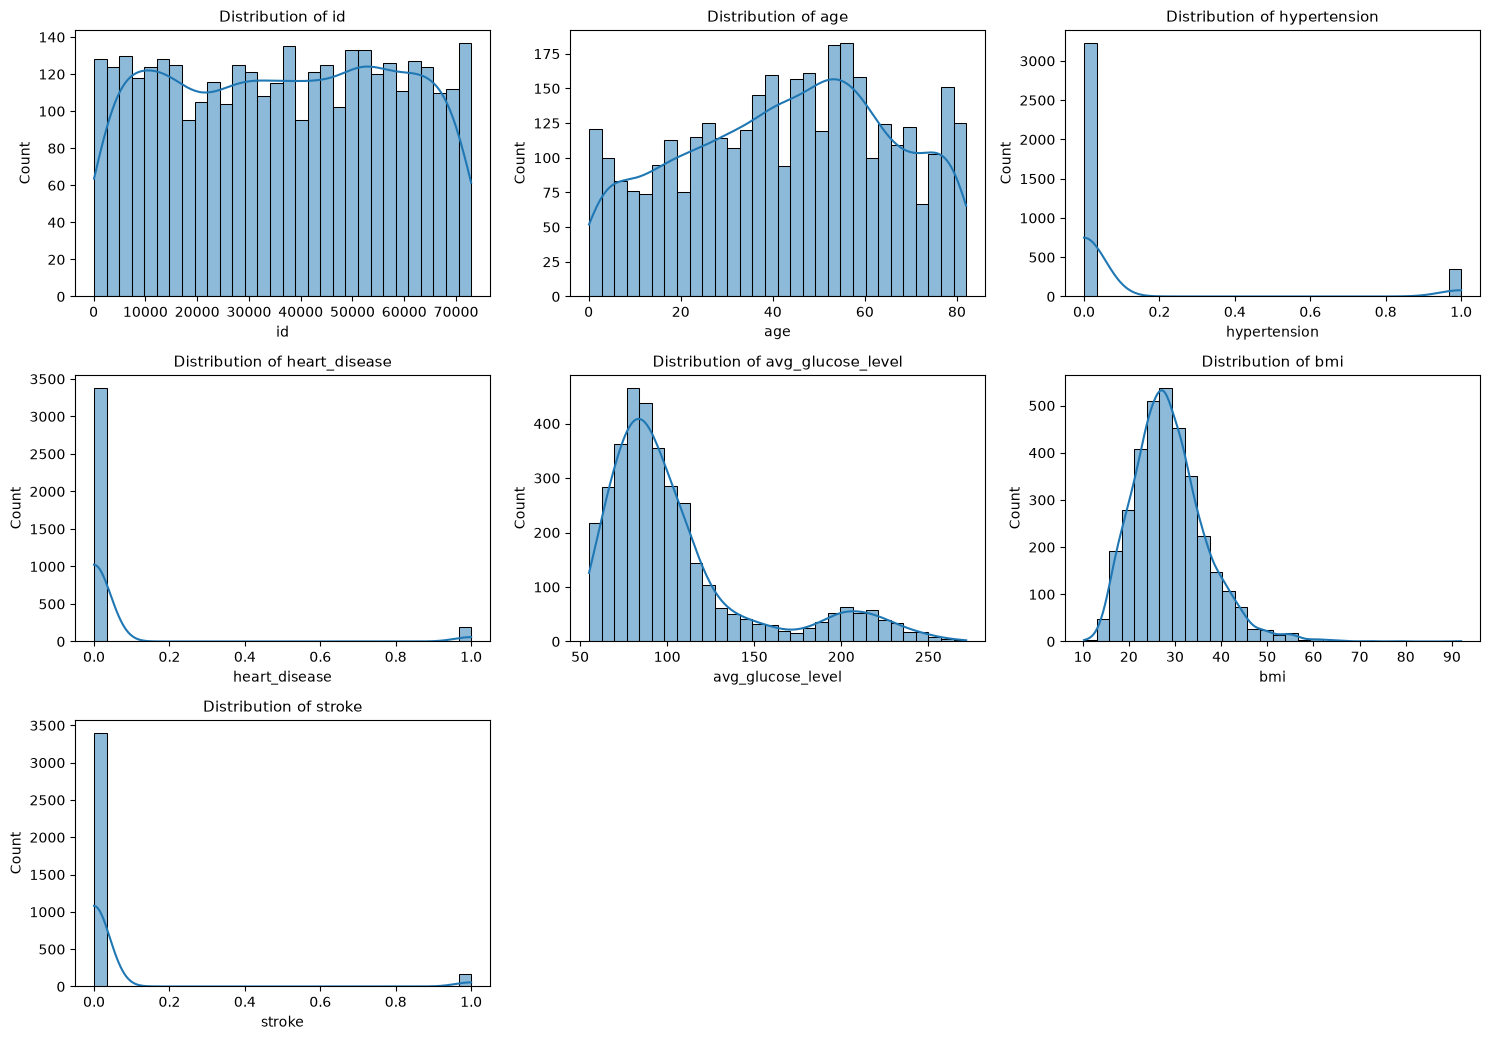

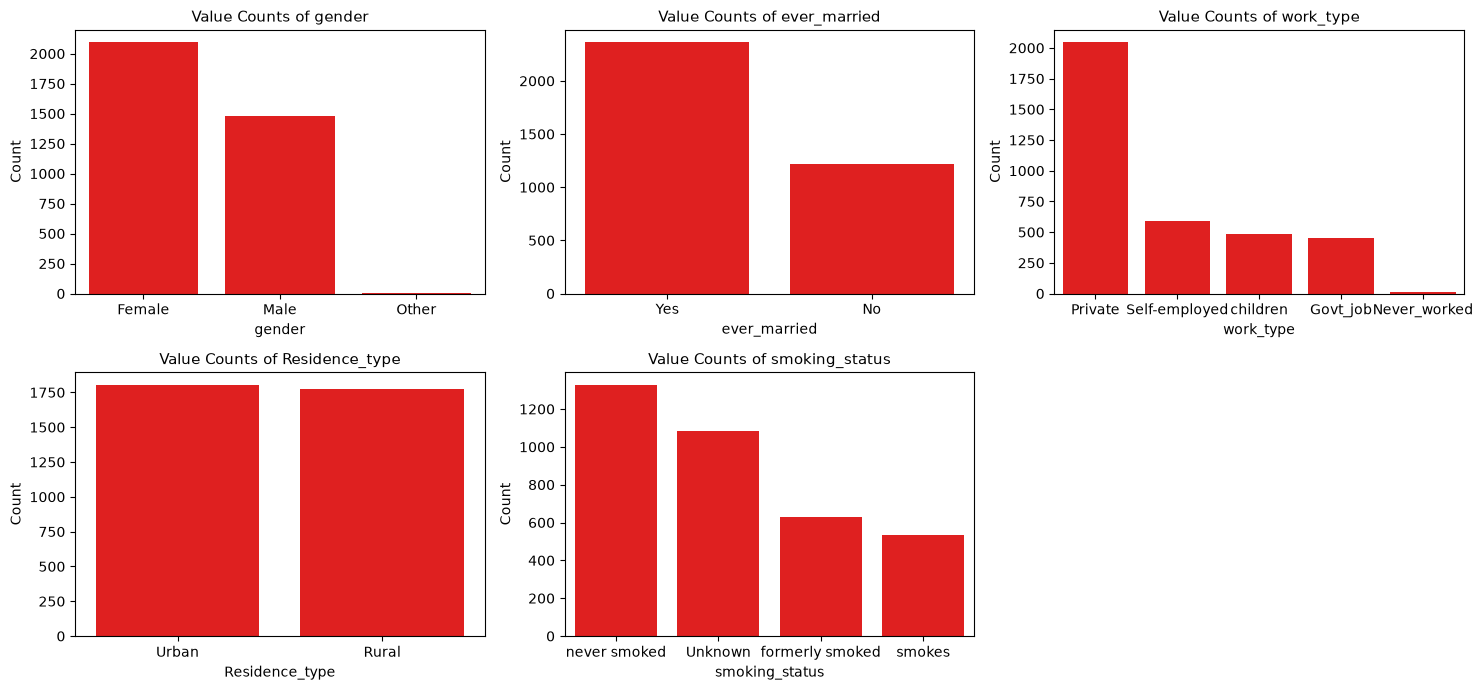

Pearson  Spearman      Abs_diff
id                id                 1.000000  1.000000  0.000000e+00
                  age                0.007223  0.005743  1.480183e-03
                  hypertension       0.010496  0.010552  5.585710e-05
                  heart_disease     -0.001444 -0.001352  9.231876e-05
                  avg_glucose_level  0.013407 -0.042459  5.586614e-02
                  bmi                0.016084  0.027556  1.147206e-02
                  stroke             0.016499  0.016634  1.348954e-04
age               id                 0.007223  0.005743  1.480183e-03
                  age                1.000000  1.000000  0.000000e+00
                  hypertension       0.268065  0.271540  3.474797e-03
                  heart_disease      0.267652  0.273461  5.808192e-03
                  avg_glucose_level  0.227899  0.133843  9.405571e-02
                  bmi                0.334056  0.378280  4.422367e-02
                  stroke             0.246029  0.251601  5.572606e-03
hypertension      id                 0.010496  0.010552  5.585710e-05
                  age                0.268065  0.271540  3.474797e-03
                  hypertension       1.000000  1.000000  0.000000e+00
                  heart_disease      0.102572  0.102572  2.359224e-16
                  avg_glucose_level  0.173432  0.106136  6.729566e-02
                  bmi                0.168515  0.168497  1.727236e-05
                  stroke             0.120188  0.120188  0.000000e+00
heart_disease     id                -0.001444 -0.001352  9.231876e-05
                  age                0.267652  0.273461  5.808192e-03
                  hypertension       0.102572  0.102572  2.359224e-16
                  heart_disease      1.000000  1.000000  0.000000e+00
                  avg_glucose_level  0.161652  0.104472  5.718019e-02
                  bmi                0.041000  0.066602  2.560179e-02
                  stroke             0.141567  0.141567  2.775558e-16
avg_glucose_level id                 0.013407 -0.042459  5.586614e-02
                  age                0.227899  0.133843  9.405571e-02
                  hypertension       0.173432  0.106136  6.729566e-02
                  heart_disease      0.161652  0.104472  5.718019e-02
                  avg_glucose_level  1.000000  1.000000  0.000000e+00
                  bmi                0.175905  0.119788  5.611665e-02
                  stroke             0.123389  0.070342  5.304673e-02
bmi               id                 0.016084  0.027556  1.147206e-02
                  age                0.334056  0.378280  4.422367e-02
                  hypertension       0.168515  0.168497  1.727236e-05
                  heart_disease      0.041000  0.066602  2.560179e-02
                  avg_glucose_level  0.175905  0.119788  5.611665e-02
                  bmi                1.000000  1.000000  0.000000e+00
                  stroke             0.034029  0.053545  1.951590e-02
stroke            id                 0.016499  0.016634  1.348954e-04
                  age                0.246029  0.251601  5.572606e-03
                  hypertension       0.120188  0.120188  0.000000e+00
                  heart_disease      0.141567  0.141567  2.775558e-16
                  avg_glucose_level  0.123389  0.070342  5.304673e-02
                  bmi                0.034029  0.053545  1.951590e-02
                  stroke             1.000000  1.000000  0.000000e+00

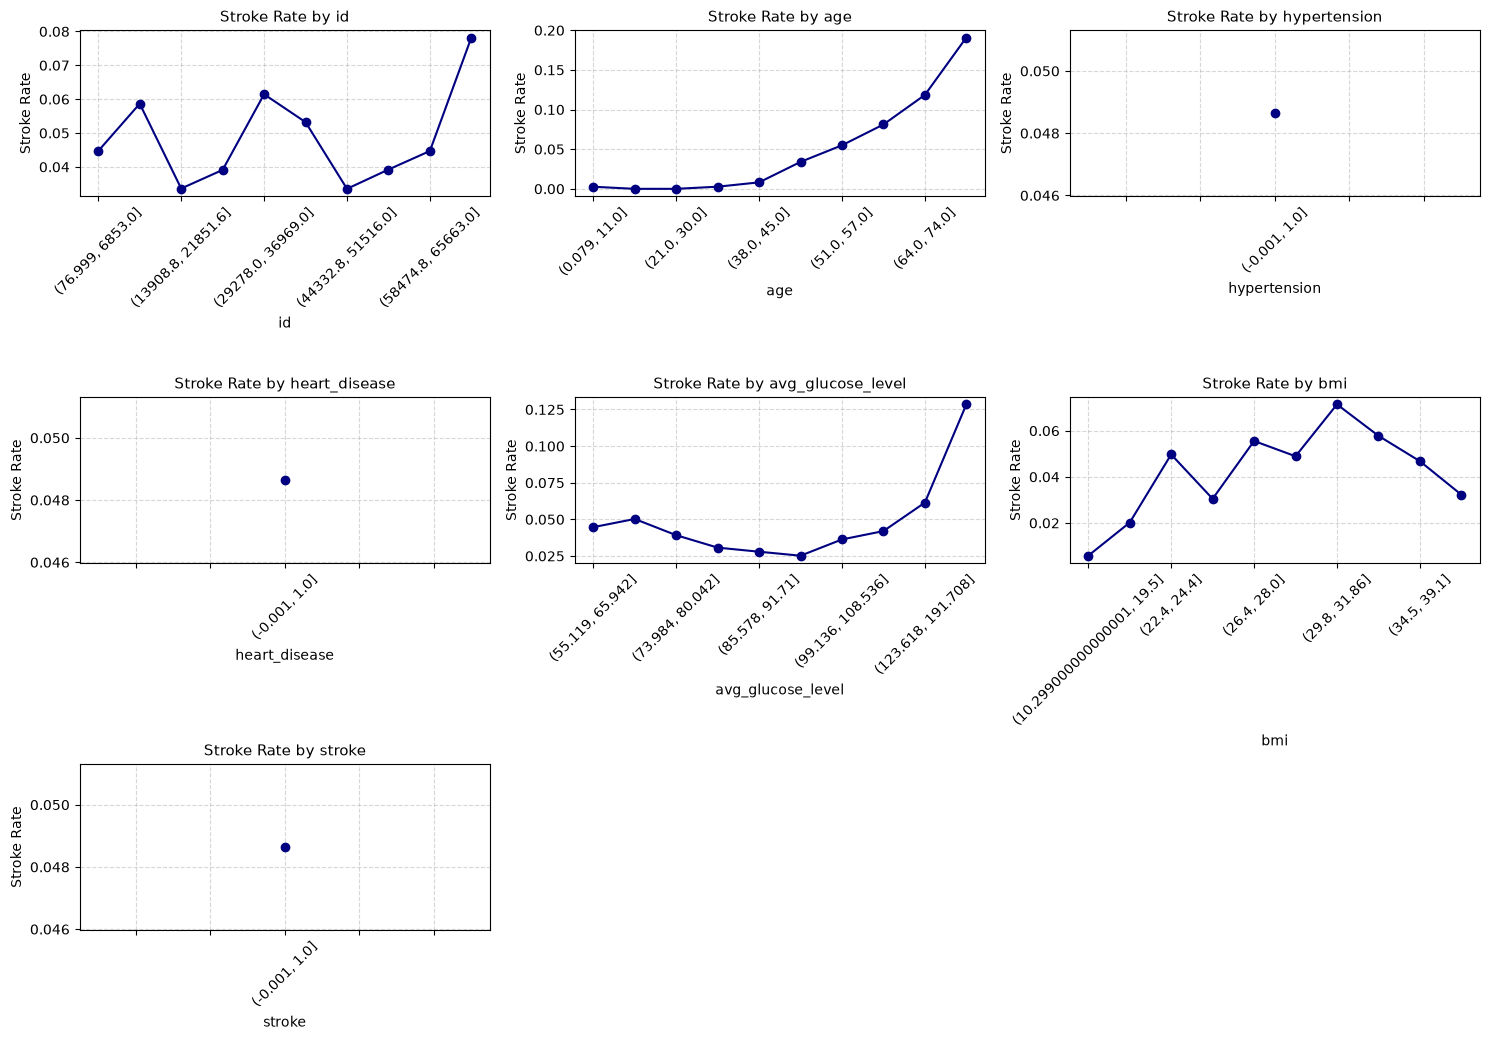

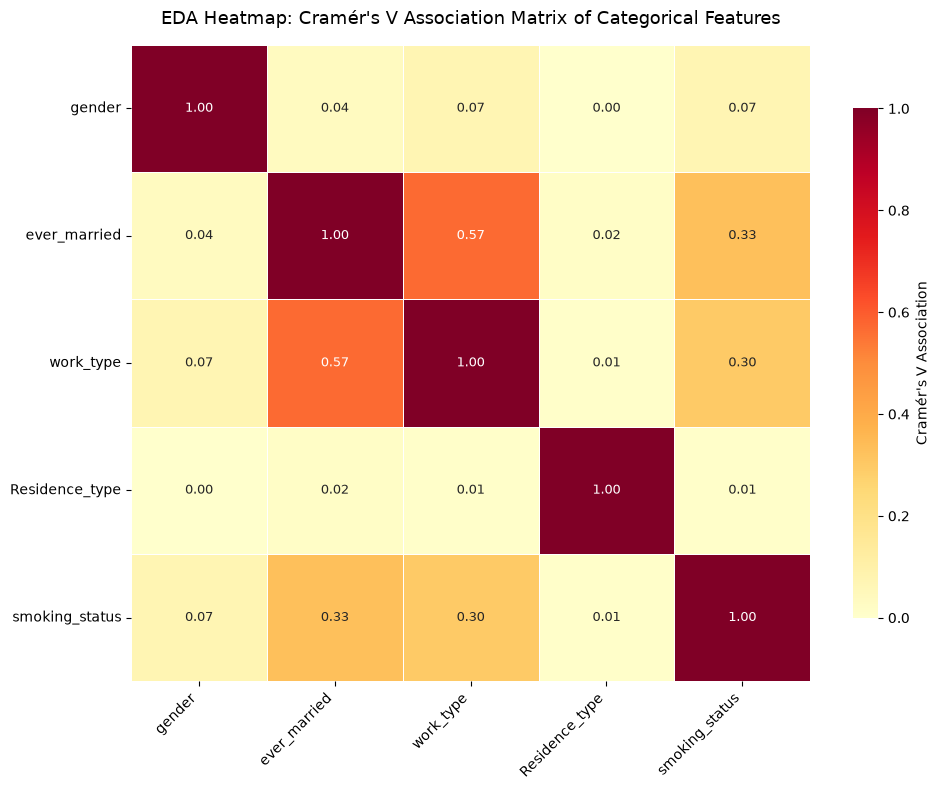

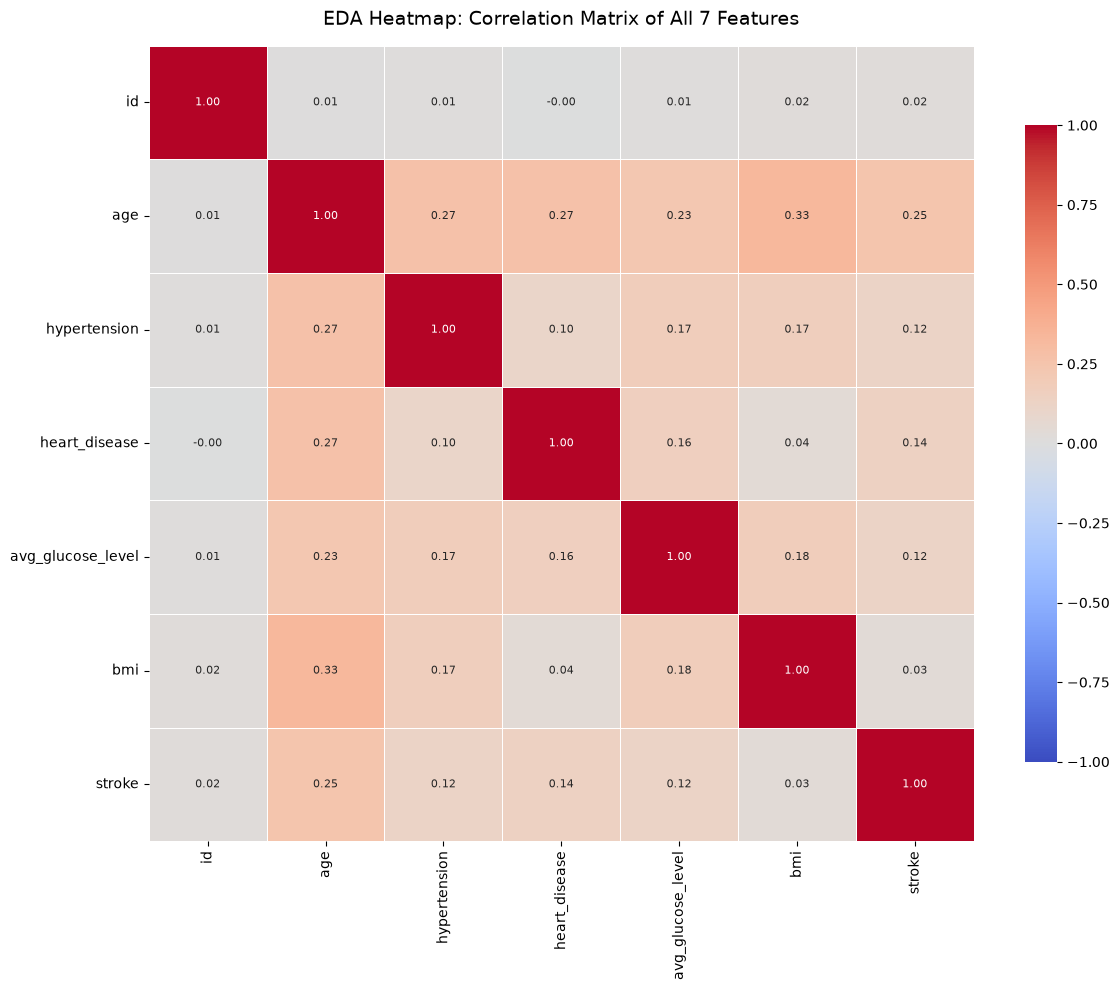

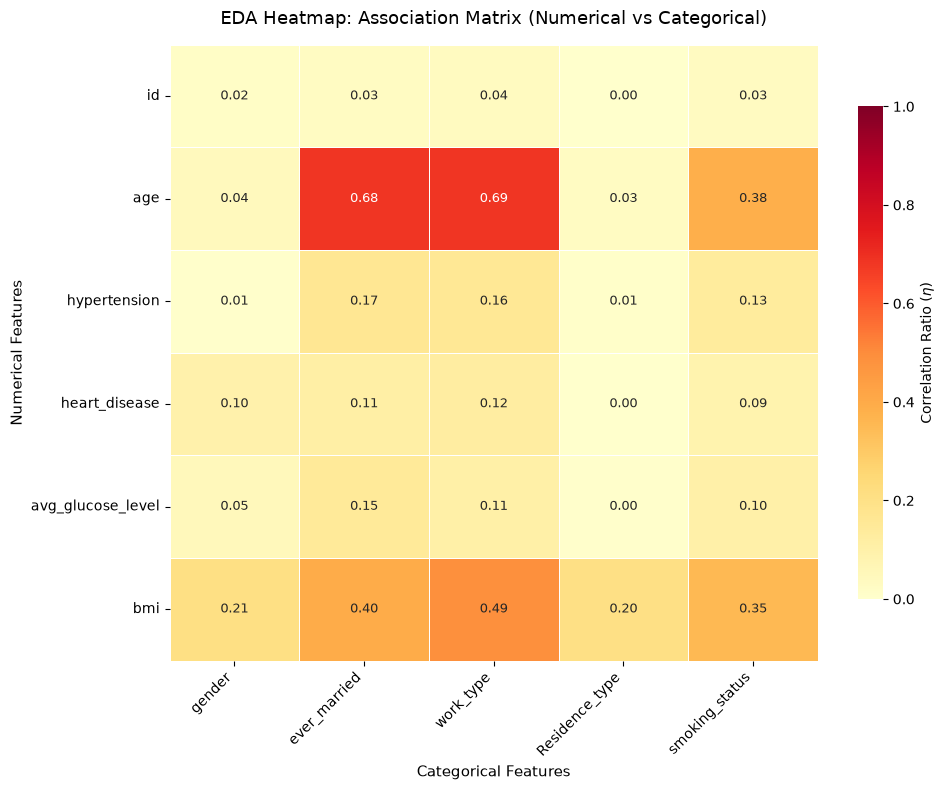

In [3]:
# Notebook 2_eda
%run 02_eda.ipynb

eda = EDA(X_splits, y_splits)

In [4]:
# Notebook 03_pre_process
%run 03_pre_process.ipynb

# Fit and transform data for Linear models with SMOTE enabled
lr_processor = Pre_Processor(model_type="linear", use_smote=True)
X_train_lr, y_train_lr = lr_processor.fit_transform(
    X_splits["X_train"], y_splits["y_train"]
)
X_val_lr, y_val_lr = lr_processor.transform(
    X_splits["X_val"], y_splits["y_val"]
)

# Fit and transform data for Tree-based models with SMOTE enabled
dt_processor = Pre_Processor(model_type="tree", use_smote=True)
X_train_dt, y_train_dt = dt_processor.fit_transform(
    X_splits["X_train"], y_splits["y_train"]
)
X_val_dt, y_val_dt = dt_processor.transform(
    X_splits["X_val"], y_splits["y_val"]
)

In [5]:
# Notebook 04_base_models
%run 04_base_models.ipynb

# 2. Run Base Models using preprocessed arrays from Cell 3
linear_base = Linear_Base_Model(
    X_train_processed=X_train_lr,
    y_train_processed=y_train_lr,
    X_val_processed=X_val_lr,
    y_val_processed=y_val_lr,
)

tree_base = Tree_Base_Model(
    X_train_processed=X_train_dt,
    y_train_processed=y_train_dt,
    X_val_processed=X_val_dt,
    y_val_processed=y_val_dt,
)

/home/alvaro/AAI501-Alvaro-Folgueira-Project/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


----------Logistic Regression Base Model--------------
Accuracy:  0.7180
Precision: 0.1224
Recall:    0.7838
F1-Score:  0.2117
ROC-AUC:   0.8449

----------Support Vector Machine Base Model--------------
Accuracy:  0.7859
Precision: 0.1006
Recall:    0.4324
F1-Score:  0.1633
ROC-AUC:   0.7491

----------K-Nearest Neighbors Base Model--------------
Accuracy:  0.8094
Precision: 0.1135
Recall:    0.4324
F1-Score:  0.1798
ROC-AUC:   0.6330

----------Decision Tree Base Model--------------
Accuracy:  0.9151
Precision: 0.1316
Recall:    0.1351
F1-Score:  0.1333
ROC-AUC:   0.5449

----------Random Forest Base Model--------------
Accuracy:  0.9452
Precision: 0.2222
Recall:    0.0541
F1-Score:  0.0870
ROC-AUC:   0.8023

----------XGBoost Base Model--------------
Accuracy:  0.9399
Precision: 0.2632
Recall:    0.1351
F1-Score:  0.1786
ROC-AUC:   0.7825



1/3 Tuning hyperparameters (Logistic Regression)...
2/3 Tuning hyperparameters (Random Forest)...
3/3 Tuning hyperparameters (XGBoost)...
Hyperparameter tuning complete.
--- Hyperparameter Tuning CV Results ---


,Model,Best ROC-AUC (CV),Best Params
0,Logistic Regression,0.8524,"{'C': 0.1, 'solver': 'liblinear'}"
1,Random Forest,0.9957,"{'max_depth': None, 'min_samples_split': 2, 'n..."
2,XGBoost,0.9928,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti..."



--- Validation Results at Optimal Thresholds ---


,Model,Optimal Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.48,0.7050,0.1205,0.8108,0.2098,0.8406
1,Random Forest,0.10,0.8042,0.1491,0.6486,0.2424,0.8023
2,XGBoost,0.10,0.8368,0.1333,0.4324,0.2038,0.8030


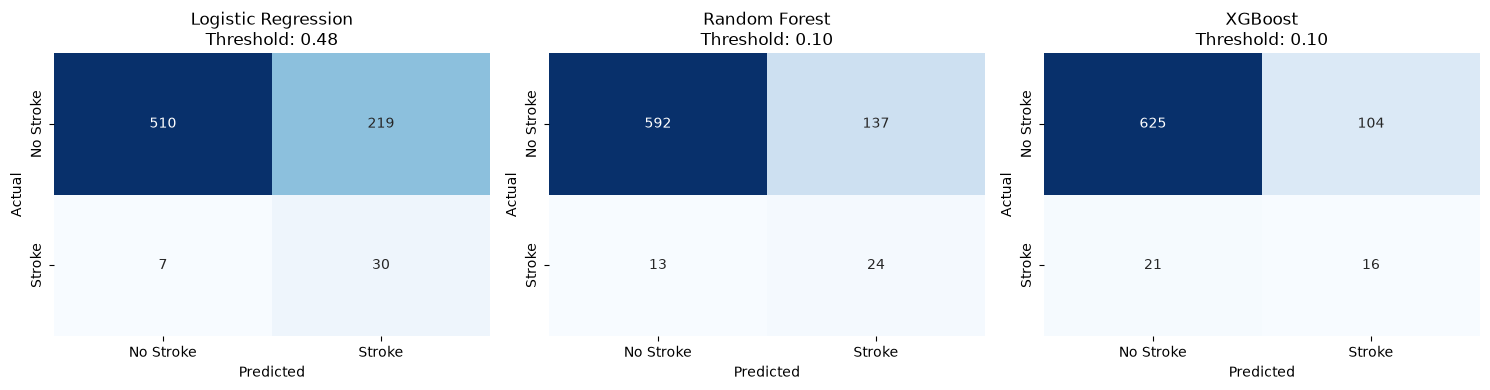

In [6]:
# Notebook 05_tune

%run 05_tune.ipynb

# Hyperparameter Tuning
hp_tuner = HyperparameterTuner(
    X_train_lr=X_train_lr,
    y_train_lr=y_train_lr,
    X_train_dt=X_train_dt,
    y_train_dt=y_train_dt,
    scale_pos_weight=1, #turned off because oversampling has been applied
)
cv_summary = hp_tuner.run_tuning()
print("--- Hyperparameter Tuning CV Results ---")
display(cv_summary)

# Threshold Tuning
threshold_tuner = ThresholdTuner(
    best_estimators=hp_tuner.best_estimators,
    X_val_lr=X_val_lr,
    y_val_lr=y_val_lr,
    X_val_dt=X_val_dt,
    y_val_dt=y_val_dt,
)
val_summary = threshold_tuner.tune_thresholds(target_metric="f1")
print("\n--- Validation Results at Optimal Thresholds ---")
display(val_summary)


threshold_tuner.plot_confusion_matrices()

--- Final Champion Model Test Set Performance ---


,Model,Optimal Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.48,0.678,0.1144,0.8158,0.2006,0.8341


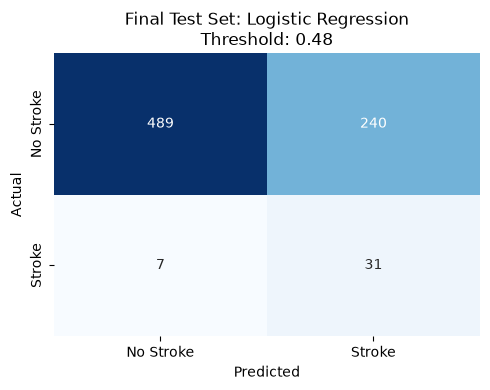

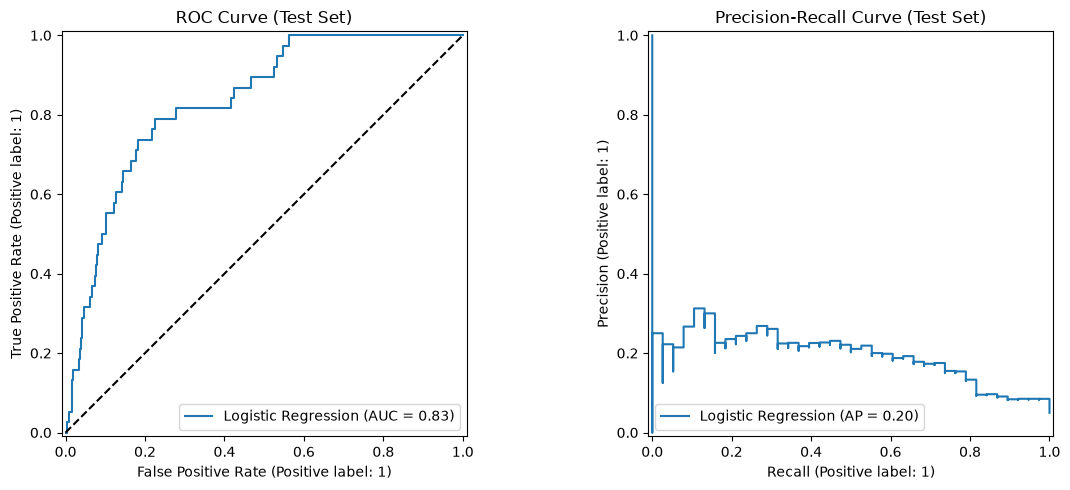

In [7]:
# Notebook 06_evaluation
%run 06_final_evaluation.ipynb

# Final Evaluation with best model
winning_model = hp_tuner.best_estimators["Logistic Regression"]
winning_thresh = threshold_tuner.optimal_thresholds["Logistic Regression"]

evaluator = ModelEvaluator(
    champion_model=winning_model,
    processor=lr_processor,
    optimal_threshold=winning_thresh,
    model_name="Logistic Regression",
)

# Final Test Set Evaluation
test_summary = evaluator.evaluate_test_set(
    X_splits["X_test"], y_splits["y_test"]
)
print("--- Final Champion Model Test Set Performance ---")
display(test_summary)

evaluator.plot_test_confusion_matrix()
evaluator.plot_diagnostic_curves()